# W3 — Monte Carlo engine check

This notebook checks the Monte Carlo part of the project.

The code itself is stored in `src/models/heston.py` and `src/pricing/variance_mc.py`.  
Here I only run the functions, inspect the simulated paths, and compare the Monte Carlo result with the analytical variance strike.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.heston import HestonParams, simulate_heston_paths
from src.pricing.variance_mc import (
    compute_realized_variance,
    heston_variance_strike,
    price_variance_swap_mc,
    price_vix_call_mc,
    run_convergence_study,
)

In [2]:
params = HestonParams(
    s0=100.0,
    v0=0.04,
    r=0.03,
    kappa=2.0,
    theta=0.04,
    sigma_v=0.5,
    rho=-0.7,
)

maturity = 1.0
steps = 252
paths = 10_000
seed = 42

params

HestonParams(s0=100.0, v0=0.04, r=0.03, kappa=2.0, theta=0.04, sigma_v=0.5, rho=-0.7)

In [3]:
times, stock_paths, variance_paths = simulate_heston_paths(
    params=params,
    maturity=maturity,
    steps=steps,
    paths=paths,
    seed=seed,
)

stock_paths.shape, variance_paths.shape

((10000, 253), (10000, 253))

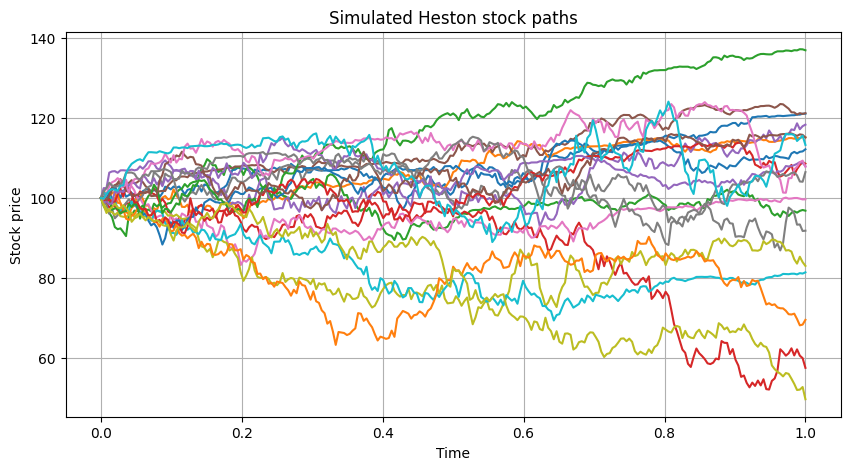

In [4]:
plt.figure(figsize=(10, 5))

for i in range(20):
    plt.plot(times, stock_paths[i])

plt.title("Simulated Heston stock paths")
plt.xlabel("Time")
plt.ylabel("Stock price")
plt.grid(True)
plt.show()

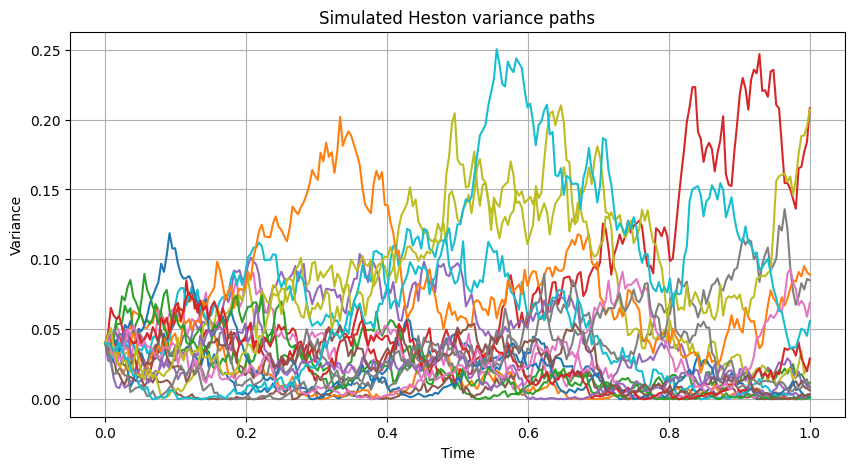

In [5]:
plt.figure(figsize=(10, 5))

for i in range(20):
    plt.plot(times, variance_paths[i])

plt.title("Simulated Heston variance paths")
plt.xlabel("Time")
plt.ylabel("Variance")
plt.grid(True)
plt.show()

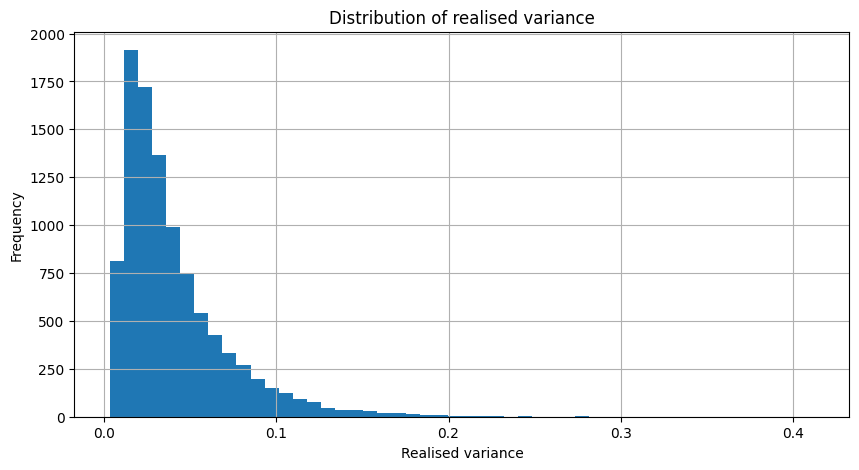

count    10000.000000
mean         0.040269
std          0.031658
min          0.003090
25%          0.018492
50%          0.030821
75%          0.051490
max          0.412461
dtype: float64

In [6]:
realized_variance = compute_realized_variance(
    stock_paths=stock_paths,
    maturity=maturity,
)

plt.figure(figsize=(10, 5))
plt.hist(realized_variance, bins=50)
plt.title("Distribution of realised variance")
plt.xlabel("Realised variance")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

pd.Series(realized_variance).describe()

In [7]:
variance_swap_result = price_variance_swap_mc(
    params=params,
    maturity=maturity,
    steps=steps,
    paths=paths,
    seed=seed,
)

pd.DataFrame([variance_swap_result])

,mc_realized_variance,ci_lower,ci_upper,analytical_k_var,used_strike,absolute_error,relative_error,swap_value
0,0.040269,0.039648,0.040889,0.04,0.04,0.000269,0.006724,0.000261


In [8]:
vix_call_result = price_vix_call_mc(
    params=params,
    option_maturity=30 / 365,
    strike=20.0,
    steps=30,
    paths=paths,
    seed=seed,
)

pd.DataFrame([vix_call_result])

,vix_call_price,undiscounted_payoff_mean,ci_lower_discounted,ci_upper_discounted,mean_terminal_vix,strike
0,1.984952,1.989852,1.919523,2.050381,18.934275,20.0


In [9]:
convergence_table = run_convergence_study(
    params=params,
    maturity=maturity,
    steps=steps,
    path_counts=[1_000, 5_000, 10_000, 50_000],
    seed=seed,
)

convergence_table

,paths,mc_realized_variance,analytical_k_var,absolute_error,relative_error,ci_width
0,1000,0.040907,0.04,0.000907,0.022672,0.004002
1,5000,0.040471,0.04,0.000471,0.011784,0.001756
2,10000,0.040269,0.04,0.000269,0.006724,0.001241
3,50000,0.040286,0.04,0.000286,0.007144,0.000549


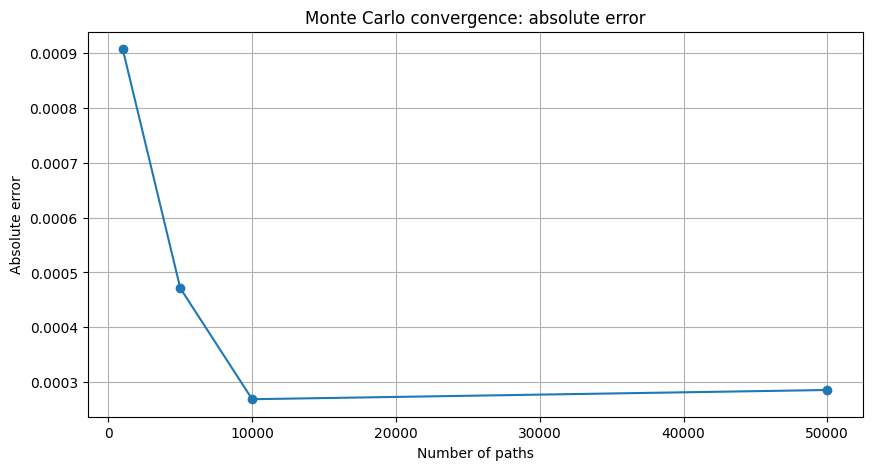

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(
    convergence_table["paths"],
    convergence_table["absolute_error"],
    marker="o",
)

plt.title("Monte Carlo convergence: absolute error")
plt.xlabel("Number of paths")
plt.ylabel("Absolute error")
plt.grid(True)
plt.show()

## Short note

The Monte Carlo estimate of realised variance is close to the analytical Heston variance strike.  
The convergence table also shows how the error changes when the number of simulated paths increases.

This notebook is only used for checking and presenting the W3 results. The reusable implementation is kept in the Python files under `src/`.